Number of concepts: 2


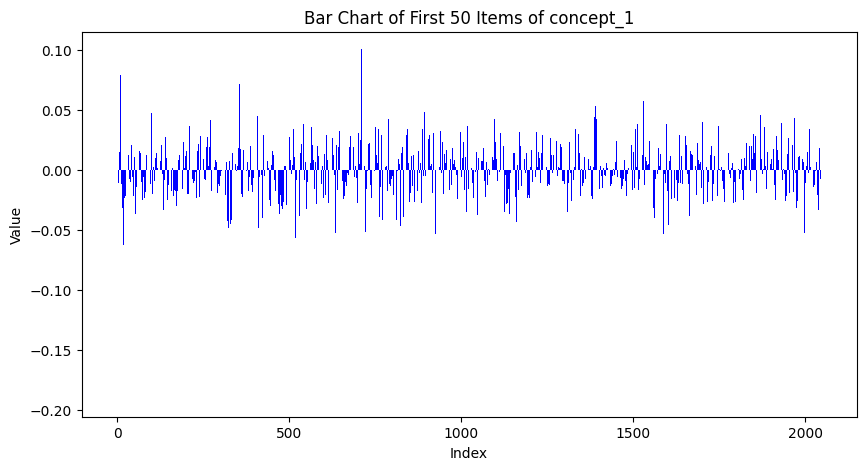

In [1]:
import torch
feature_path = "/mnt/abka03/concept_extraction_result/oneclass/gemma3n/MCoX/SNMF/rabbit/train/concept/decompose_activations_text_grounding_image_grounding__gemma3n_results_patch_all_patch_snmf.pth"
data = torch.load(feature_path, map_location="cpu")

hidden_states = data["concepts"]
print(f"Number of concepts: {len(hidden_states)}")
concept_1 = hidden_states[1]
import matplotlib.pyplot as plt

# Select the first 50 items of concept_1
indices = list(range(2048))
values = concept_1[:2048].numpy()

# Create a bar chart
plt.figure(figsize=(10, 5))
plt.bar(indices, values, color='blue')
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Bar Chart of First 50 Items of concept_1")
plt.show()

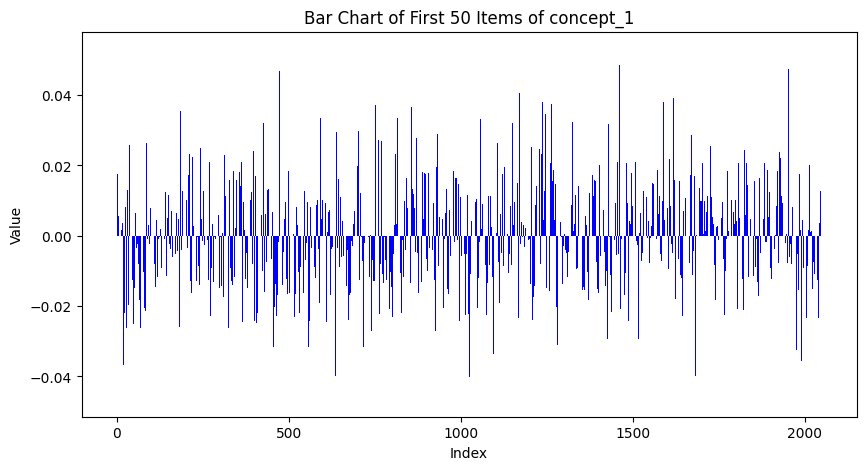

In [2]:
hidden_states_ij = []
for i in range(len(hidden_states)):
    for j in range(len(hidden_states)):
        if i != j:
            hidden_states_ij.append(hidden_states[i] - hidden_states[j])
steering_vector = hidden_states_ij[1]

# Select the first 50 items of concept_1
indices = list(range(2048))
values = steering_vector.numpy()

# Create a bar chart
plt.figure(figsize=(10, 5))
plt.bar(indices, values, color='blue')
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Bar Chart of First 50 Items of concept_1")
plt.show()



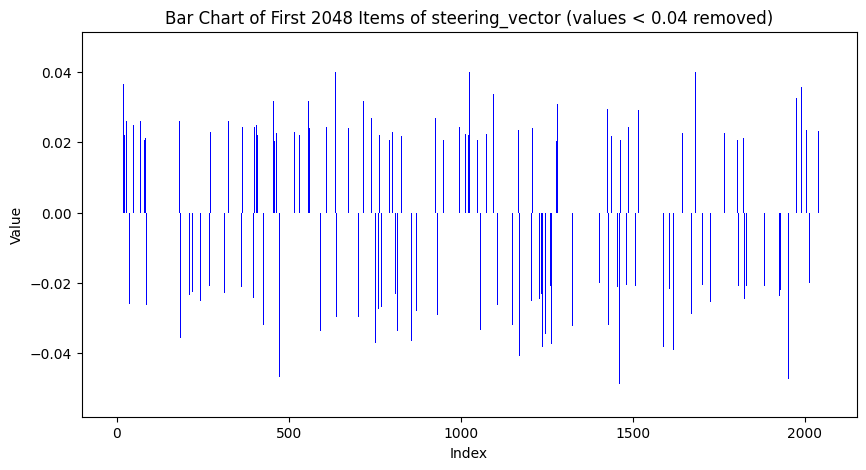

In [3]:
hidden_states_ij = []
for i in range(len(hidden_states)):
    for j in range(len(hidden_states)):
        if i != j:
            hidden_states_ij.append(hidden_states[i] - hidden_states[j])
# Remove values below 0.04 in steering_vector
steering_vector = hidden_states_ij[0].clone()
steering_vector[steering_vector.abs() < 0.02] = 0

# Select the first 2048 items of steering_vector
indices = list(range(2048))
values = steering_vector[:2048].numpy()

# Create a bar chart
plt.figure(figsize=(10, 5))
plt.bar(indices, values, color='blue')
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Bar Chart of First 2048 Items of steering_vector (values < 0.04 removed)")
plt.show()

In [ ]:
# Find the second and third max indices and values for each concept
second_max_indices = [concept.topk(3).indices[1].item() for concept in hidden_states]
third_max_indices = [concept.topk(3).indices[2].item() for concept in hidden_states]

second_max_values = [concept.topk(3).values[1].item() for concept in hidden_states]
third_max_values = [concept.topk(3).values[2].item() for concept in hidden_states]

print("Second max index for each concept:", second_max_indices)
print("Second max value for each concept:", second_max_values)
print("Third max index for each concept:", third_max_indices)
print("Third max value for each concept:", third_max_values)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
feature_path = "/mnt/abka03/concept_extraction_result/MCoX/SNMF/layer_norm_imagenet3/train/features/save_hidden_states_sentence_qw3een2.pth"
data = torch.load(feature_path, map_location="cpu")
data = data["hidden_states"][0]['model.language_model.layers.30.input_layernorm'].squeeze()
# Ensure both vectors are 1D and of the same length and dtype
data = data.flatten().to(torch.float32)
concept = concept_1.flatten().to(torch.float32)

# Store cosine similarities for each index
cosine_similarities = []
for i in range(len(data)):
    # Create vectors with only the i-th index nonzero
    data_i = torch.zeros_like(data)
    concept_i = torch.zeros_like(concept)
    data_i[i] = data[i]
    concept_i[i] = concept[i]
    # Compute cosine similarity (if both are nonzero)
    if data_i.norm() > 0 and concept_i.norm() > 0:
        sim = torch.dot(data_i, concept_i) / (data_i.norm() * concept_i.norm())
    else:
        sim = 0.0
    cosine_similarities.append(sim)

# Convert to numpy for sorting
cosine_similarities_np = np.array(cosine_similarities)

# Find top-k indices responsible for highest cosine similarity
top_k = 20
top_indices = np.argsort(cosine_similarities_np)[-top_k:][::-1]

print("\n=== Top 20 Indices Responsible for Highest Cosine Similarity ===")
for rank, idx in enumerate(top_indices, 1):
    print(f"Rank {rank:2d}: Index {idx:4d} | Cosine Similarity: {cosine_similarities_np[idx]:.6f} | data[{idx}]: {data[idx]:.4f} | concept_1[{idx}]: {concept[idx]:.4f}")

# Plot the cosine similarity for each index
plt.figure(figsize=(10, 5))
plt.plot(cosine_similarities, marker='o')
plt.xlabel("Index")
plt.ylabel("Cosine Similarity (Angular Contribution)")
plt.title("Angular Contribution of Each Index to Cosine Similarity")
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
feature_path = "/mnt/abka03/concept_extraction_result/MCoX/SNMF/layer_norm_imagenet3/train/features/save_hidden_states_sentence_qw3een2.pth"
data = torch.load(feature_path, map_location="cpu")
data = data["hidden_states"][0]['model.language_model.layers.30.input_layernorm'].squeeze()
# Ensure both vectors are 1D and of the same length and dtype
data = data.flatten().to(torch.float32)
concept = concept_1.flatten().to(torch.float32)

# Normalize both vectors
data_norm = data / data.norm()
concept_norm = concept / concept.norm()

# Element-wise product (contribution to cosine similarity)
contributions = data_norm * concept_norm

# Get absolute contributions for ranking
abs_contributions = torch.abs(contributions)

# Find top-k indices with highest absolute contribution
top_k = 20
top_indices = torch.topk(abs_contributions, top_k).indices.cpu().numpy()

print("\n=== Top 20 Indices Contributing Most to Cosine Similarity ===")
for rank, idx in enumerate(top_indices, 1):
    print(f"Rank {rank:2d}: Index {idx:4d} | Contribution: {contributions[idx]:.6f} | data_norm[{idx}]: {data_norm[idx]:.4f} | concept_norm[{idx}]: {concept_norm[idx]:.4f}")

# Visualize the top-k contributions
plt.figure(figsize=(10, 5))
plt.bar(range(top_k), contributions[top_indices].cpu().numpy(), color='blue')
plt.xticks(range(top_k), top_indices)
plt.xlabel("Top Index (by Contribution)")
plt.ylabel("Contribution to Cosine Similarity")
plt.title("Top 20 Index Contributions to Cosine Similarity")
plt.show()
print("Top 20 indices contributing most to cosine similarity:")

print(top_indices)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def normalize(v):
    return v / np.linalg.norm(v)

# Feature vectors (unit)
f_dog = normalize(np.array([2, 3]))
f_cat = normalize(np.array([-1, -2]))

# Example activation vectors
activations = [
    np.array([1.22667242, 0.87619458]),
    np.array([-1.3123357, -0.78740142]),
    np.array([1.32380284, -0.7942817]),
    np.array([-0.67514286, -1.35028572]),
]

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs = axs.flatten()

for i, (ax, act) in enumerate(zip(axs, activations)):
    # Projections (scalar)
    alpha_dog = np.dot(act, f_dog)
    alpha_cat = np.dot(act, f_cat)

    print(f"Activation {i+1}: alpha_dog = {alpha_dog:.3f}, alpha_cat = {alpha_cat:.3f}")

    # Projection vectors
    proj_dog = alpha_dog * f_dog
    proj_cat = alpha_cat * f_cat
    proj_sum = proj_dog + proj_cat

    origin = np.zeros(2)

    # Plot feature vectors
    ax.quiver(*origin, *f_dog, color='blue', scale_units='xy', scale=1, width=0.007, label='Feature: Dog (unit)')
    ax.quiver(*origin, *f_cat, color='green', scale_units='xy', scale=1, width=0.007, label='Feature: Cat (unit)')

    # Plot activation vector
    ax.quiver(*origin, *act, color='red', width=0.01, scale_units='xy', scale=1, label='Activation')

    # Plot projections - positive and negative differently styled
    # Dog projection
    if alpha_dog >= 0:
        ax.quiver(*origin, *proj_dog, color='cyan', width=0.007, scale_units='xy', scale=1, label='Projection on Dog (+)')
    else:
        ax.quiver(*origin, *proj_dog, color='cyan', alpha=0.5, width=0.007, scale_units='xy', scale=1, label='Projection on Dog (-)')


    # Cat projection (start at tip of proj_dog)
    if alpha_cat >= 0:
        ax.quiver(*proj_dog, *proj_cat, color='purple', width=0.007, scale_units='xy', scale=1, label='Projection on Cat (+)')
    else:
        ax.quiver(*proj_dog, *proj_cat, color='purple', alpha=0.5, width=0.007, scale_units='xy', scale=1, label='Projection on Cat (-)')


    # Sum of projections (reconstructed vector)
    ax.quiver(*origin, *proj_sum, color='orange', width=0.007, scale_units='xy', scale=1, label='Sum of Projections')

    # Annotations
    ax.text(*(f_dog + 0.1), 'f_dog', color='blue', fontsize=10)
    ax.text(*(f_cat + 0.1), 'f_cat', color='green', fontsize=10)
    ax.text(*(act + 0.15), f'Activation {i+1}', color='red', fontsize=10)
    ax.text(*(proj_sum + 0.15), 'Reconstruction', color='orange', fontsize=10)

    # Formatting
    ax.set_xlim(-3, 4)
    ax.set_ylim(-3, 4)
    ax.set_aspect('equal', 'box')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Feature dimension 1')
    ax.set_ylabel('Feature dimension 2')
    ax.set_title(f'Activation Vector {i+1} Projection')

# Single legend for all subplots
handles, labels = axs[0].get_legend_handles_labels()

# Remove duplicates in legend
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=4, fontsize=12)

plt.suptitle('Projection of Activation Vectors onto Feature Vectors (with signed dot products)', fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


In [ ]:
import torch
import numpy as np

# Ensure both vectors are 1D and of the same length
data = data.flatten()
concept = concept_1.flatten()

# Normalize both vectors
data_norm = data / data.norm()
concept_norm = concept / concept.norm()

# Compute cosine similarity for each index (element-wise product)
cosine_similarities = data_norm * concept_norm

# Find the index with the maximum cosine similarity
max_index = torch.argmax(cosine_similarities).item()
max_value = cosine_similarities[max_index].item()

print(f"Index with maximum cosine similarity: {max_index}")
print(f"Maximum cosine similarity value: {max_value}")

In [ ]:
import torch
import torch.nn.functional as F
embeddings_path = torch.load("/mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/cifar100/val/features/save_hidden_states_sentence_qwen2_patched_image_apple_token_of_interest_concept_generation_split_val.pth")
embeddings = torch.stack([hid["model.language_model.norm"][0][0] for hid in embeddings_path["hidden_states"]])
print(f"Number of activations: {embeddings.shape}")  # Should be 100
feature_path = torch.load("/mnt/abka03/concept_extraction_result/publish/gemma3n/DL/SNMF/cifar100/train/concept/decompose_activations_text_grounding_image_grounding_gemma3n_results_patch_all_patch_simple.pth")
features = feature_path["concepts"]
features = features.to(dtype=torch.float32)
embeddings = embeddings.to(dtype=torch.float32)

features_norm = F.normalize(features, dim=1)      # (20, 2000)
activations_norm = F.normalize(embeddings, dim=1)  # (100, 2000)

# Compute cosine similarity: (100, 20)
similarity = torch.matmul(activations_norm, features_norm.T)

# Get indices of top-1 most similar feature vector for each activation
top_feature_indices = similarity.argmax(dim=1)  # shape: (100,)

# Select the most similar feature vector for each activation
activations = features[top_feature_indices]  # shape: (100, 2000)


In [ ]:
import numpy as np

def cosine_similarity_matrix(embeddings):
    """
    Compute pairwise cosine similarity matrix for embeddings.
    embeddings: (N, d) numpy array
    returns: (N, N) similarity matrix with values in [-1, 1]
    """
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / (norms + 1e-10)  # avoid div by zero
    return normalized @ normalized.T  # cosine similarity matrix

def min_max_normalize(arr):
    """Min-max normalize a 1D array to [0,1]."""
    min_val = arr.min()
    max_val = arr.max()
    if max_val == min_val:
        return np.zeros_like(arr)
    return (arr - min_val) / (max_val - min_val)

def compute_monoscore(X, embeddings):
    """
    Compute MonoSemanticity score per neuron.
    
    X: (N, omega) activations matrix
    embeddings: (N, d) embeddings from f(x)
    
    Returns:
      MS_scores: (omega,) array of monoscores for each neuron
    """
    N, omega = X.shape

    # 1. Compute pairwise similarity matrix S (N x N)
    S = cosine_similarity_matrix(embeddings)
    MS_scores = np.zeros(omega)
    for k in range(omega):
        # 2. Get activations for neuron k
        ak = X[:, k]
        # 3. Normalize activations to [0,1]
        ak_norm = min_max_normalize(ak)

        # 4. Compute relevance matrix R = ak_norm_n * ak_norm_m (outer product)
        R = np.outer(ak_norm, ak_norm)

        # 5. Exclude diagonal pairs (n == m) by zeroing them
        np.fill_diagonal(R, 0)

        # 6. Compute weighted average similarity for neuron k
        total_weight = R.sum()
        if total_weight == 0:
            MS_scores[k] = 0  # no strong activations
        else:
            MS_scores[k] = (R * S).sum() / total_weight

    return MS_scores
import numpy as np

# Assuming features_path["concepts"] exists and contains the data

# Convert both to numpy arrays
activations_np = activations.detach().cpu().numpy()
embeddings_np = embeddings.detach().cpu().numpy()

# Call your function
scores = compute_monoscore(activations_np, embeddings_np)

print( np.sort(scores)[-500:-1] )
print(scores.shape)

In [ ]:
import torch
import torch.nn.functional as F

# Load data
embeddings_path = torch.load("/mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/cifar100/val/features/combined_features.pth")
embeddings = torch.stack([hid["model.language_model.norm"][0][0] for hid in embeddings_path["hidden_states"]])

feature_dict = torch.load("//mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/imagenet1000/train/concept/redefine_activations_text_grounding_snmf_combined_concept_snmf_gl_regrounded.pth")
features = feature_dict["concepts"].to(dtype=torch.float32)[1:20]
embeddings = embeddings.to(dtype=torch.float32)
features_norm = F.normalize(features, dim=1)
activations_norm = F.normalize(embeddings, dim=1)

# Cosine similarity
similarity = torch.matmul(activations_norm, features_norm.T)  # shape: (num_activations, num_features)

# -------- Select ONLY the k-th most similar --------
k = 0  # 0-based index → e.g. k=0 is top-1, k=1 is 2nd best, etc.

# Sort similarities in descending order and get indices
sorted_similarities, sorted_indices = torch.sort(similarity, dim=1, descending=True)

# Get only the k-th most similar index
kth_indices = sorted_indices[:,k]  # shape: (num_activations,)

# Gather the k-th most similar feature vectors
kth_features = features[kth_indices]  # shape: (num_activations, feature_dim)
activations = kth_features
# ---------------------------------------------------

print(f"Selected only the {k+1}-th most similar feature per activation. Shape: {kth_features.shape}")


In [ ]:
import numpy as np

def cosine_similarity_matrix(embeddings):
    """
    Compute pairwise cosine similarity matrix for embeddings.
    embeddings: (N, d) numpy array
    returns: (N, N) similarity matrix with values in [-1, 1]
    """
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / (norms + 1e-10)  # avoid div by zero
    return normalized @ normalized.T  # cosine similarity matrix

def min_max_normalize(arr):
    """Min-max normalize a 1D array to [0,1]."""
    min_val = arr.min()
    max_val = arr.max()
    if max_val == min_val:
        return np.zeros_like(arr)
    return (arr - min_val) / (max_val - min_val)

def compute_monoscore(X, embeddings):
    """
    Compute MonoSemanticity score per neuron.
    
    X: (N, omega) activations matrix
    embeddings: (N, d) embeddings from f(x)
    
    Returns:
      MS_scores: (omega,) array of monoscores for each neuron
    """
    N, omega = X.shape

    # 1. Compute pairwise similarity matrix S (N x N)
    S = cosine_similarity_matrix(embeddings)
    MS_scores = np.zeros(omega)
    for k in range(omega):
        # 2. Get activations for neuron k
        ak = X[:, k]
        # 3. Normalize activations to [0,1]
        ak_norm = min_max_normalize(ak)

        # 4. Compute relevance matrix R = ak_norm_n * ak_norm_m (outer product)
        R = np.outer(ak_norm, ak_norm)

        # 5. Exclude diagonal pairs (n == m) by zeroing them
        np.fill_diagonal(R, 0)

        # 6. Compute weighted average similarity for neuron k
        total_weight = R.sum()
        if total_weight == 0:
            MS_scores[k] = 0  # no strong activations
        else:
            MS_scores[k] = (R * S).sum() / total_weight

    return MS_scores
import numpy as np

# Assuming features_path["concepts"] exists and contains the data

# Convert both to numpy arrays
activations_np = activations.detach().cpu().numpy()
embeddings_np = embeddings.detach().cpu().numpy()

# Call your function
scores = compute_monoscore(activations_np, embeddings_np)
print(f"Computed mean MonoSemanticity scores for {np.mean(scores)} neurons.")
print(f"Computed Sd MonoSemanticity scores for {np.std(scores)} neurons.")



In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from typing import Tuple
import random
import time

# ----------------------------- CONFIG -----------------------------
EMBEDDINGS_PATH = "/mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/coco10/val/features/save_hidden_states_sentence_qwen2_patched_image_truck_token_of_interest_concept_generation_split_val.pth"
FEATURES_PATH = "/mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/coco10/train/concept/redefine_activations_text_grounding_simple_combined_concept_simple_gl_regrounded.pth"

TOP_K = 0 # index, 0=top-1, 1=top-2
USE_RANDOM_SIMILARITY = False
RANDOM_SEED = 42
NORMALIZE_FEATURES = True
NORMALIZE_EMBEDDINGS = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# ------------------------------------------------------------------

def load_data(
    embeddings_path: str, 
    features_path: str,
    device: str
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    emb_data = torch.load(embeddings_path, map_location=device)

    image_embeddings = torch.stack([
        hid["model.vision_tower.timm_model.msfa.norm"][0][0]
        for hid in emb_data["hidden_states"]
    ]).to(dtype=torch.float32, device=device)

    # <-- add reshape here (just in case it's not [N, D]) -->
    image_embeddings = image_embeddings.reshape(image_embeddings.shape[0], -1)

    lang_embeddings = torch.stack([
        hid["model.language_model.norm"][0][0]
        for hid in emb_data["hidden_states"]
    ]).to(dtype=torch.float32, device=device)

    lang_embeddings = lang_embeddings.reshape(lang_embeddings.shape[0], -1)

    feature_data = torch.load(features_path, map_location=device)
    features = feature_data["concepts"].to(dtype=torch.float32, device=device)
    # Typically features are already [num_concepts, D], but can add a .reshape if needed

    return lang_embeddings, image_embeddings, features

def get_similarity(
    lang_embeddings: torch.Tensor, 
    features: torch.Tensor,
    normalize_features: bool=True, 
    normalize_embeddings: bool=True
) -> torch.Tensor:
    if normalize_features:
        features = F.normalize(features, dim=1)
    if normalize_embeddings:
        lang_embeddings = F.normalize(lang_embeddings, dim=1)
    return torch.matmul(lang_embeddings, features.T)

def select_features(
    similarity: torch.Tensor, 
    features: torch.Tensor, 
    k: int=0, 
    use_random: bool=False, 
    seed: int=None
) -> Tuple[torch.Tensor, torch.Tensor]:
    sorted_indices = similarity.argsort(dim=1, descending=True)
    if use_random:
        if seed is not None:
            torch.manual_seed(seed)
            np.random.seed(seed)
        rand_indices = torch.randint(0, sorted_indices.size(1), (sorted_indices.size(0),), device=sorted_indices.device)
        chosen_indices = sorted_indices[torch.arange(len(rand_indices)), rand_indices]
    else:
        chosen_indices = sorted_indices[:, k]
    selected_features = features[chosen_indices]
    return selected_features, chosen_indices

def cosine_similarity_matrix_torch(X: torch.Tensor) -> torch.Tensor:
    X = F.normalize(X, dim=1)
    return X @ X.T

def compute_monoscore_torch(
    activations: torch.Tensor, 
    image_embeddings: torch.Tensor, 
    threshold_percentile: float=10.
) -> torch.Tensor:
    """
    activations:  [batch_size, num_features]
    image_embeddings: [batch_size, dim]
    """
    num_features = activations.shape[1]
    # Precompute similarity matrix over embeddings (N x N)
    img_sim = cosine_similarity_matrix_torch(image_embeddings) # [N,N]
    monoscores = torch.zeros(num_features, device=activations.device)
    N = activations.shape[0]
    for k in range(num_features):
        ak = activations[:, k]
        threshold = torch.quantile(ak, threshold_percentile / 100.0)
        ak_bin = (ak >= threshold).float() # (N,)
        act_sum = ak_bin.sum().item()
        if act_sum < 2:
            monoscores[k] = 0
            continue
        R = torch.ger(ak_bin, ak_bin) # outer
        R.fill_diagonal_(0)
        total_weight = R.sum()
        monoscores[k] = (R * img_sim).sum() / total_weight if total_weight != 0 else 0
    return monoscores.cpu()

def main():
    t0 = time.time()
    lang_emb, img_emb, features = load_data(EMBEDDINGS_PATH, FEATURES_PATH, DEVICE)
    print(f"Loaded lang_emb {lang_emb.shape} | img_emb {img_emb.shape} | features {features.shape}")
    similarity = get_similarity(
        lang_emb, features,
        normalize_features=NORMALIZE_FEATURES,
        normalize_embeddings=NORMALIZE_EMBEDDINGS
    )
    selected_features, indices = select_features(
        similarity, features,
        k=TOP_K, use_random=USE_RANDOM_SIMILARITY, seed=RANDOM_SEED
    )
    print(f"Selected {'random' if USE_RANDOM_SIMILARITY else f'top-{TOP_K + 1}'} feature per example. Shape: {selected_features.shape}")

    # If you want more features (all of them), use a slice, otherwise stick with current
    # (N, feature_dim): selected_features

    # activations: each row = sample's selected "concept" neuron activations
    monoscores = compute_monoscore_torch(selected_features, img_emb)
    t1 = time.time()

    print("\n--- MonoSemanticity Score ---")
    print(f"Mean Score: {monoscores.mean().item():.4f}")
    print(f"Std Dev  : {monoscores.std().item():.4f}")
    print(f"Finished in {t1 - t0:.1f} seconds")

if __name__ == "__main__":
    main()

In [ ]:

import torch
import torch.nn.functional as F
import numpy as np
import os
import itertools

from typing import Tuple, List

# ========== USER CONFIG =============
EMBEDDINGS_ROOT = "/mnt/abka03/concept_extraction_result/publish/gemma3n/DL/SNMF/coco10/val/features"
FEATURES_ROOT = "/mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/coco10/train/concept"
TOP_K = 0
USE_RANDOM_SIMILARITY = False
RANDOM_SEED = 42
NORMALIZE_FEATURES = True
NORMALIZE_EMBEDDINGS = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Files to use (edit the paths if files are in subdirs)
FEATURE_FILENAMES = [
    "decompose_activations_text_grounding_image_grounding__gemma3n_results_patch_all_patch_pca.pth",
    "decompose_activations_text_grounding_image_grounding__gemma3n_results_patch_all_patch_sae2.pth",
    "decompose_activations_text_grounding_image_grounding__gemma3n_results_patch_all_patch_simple.pth",
    "decompose_activations_text_grounding_image_grounding__gemma3n_results_patch_all_patch_snmf.pth"
]
EMBEDDING_FILENAMES = [
    "save_hidden_states_for_token_of_interest_qwen2_patched_image_airplane_token_of_interest_concept_generation_split_val.pth",
    "save_hidden_states_for_token_of_interest_qwen2_patched_image_car_token_of_interest_concept_generation_split_val.pth",
]
# ====================================

def get_selected_files(root: str, wanted_names: List[str]) -> List[str]:
    return [
        os.path.join(root, fname)
        for fname in wanted_names if os.path.isfile(os.path.join(root, fname))
    ]

def load_data(embeddings_path: str, features_path: str, device: str):
    emb_data = torch.load(embeddings_path, map_location=device)
    image_embeddings = torch.stack([
        hid["model.vision_tower.timm_model.msfa.norm"][0][0]
        for hid in emb_data["hidden_states"]
    ]).to(dtype=torch.float32, device=device)
    image_embeddings = image_embeddings.reshape(image_embeddings.shape[0], -1)
    lang_embeddings = torch.stack([
        hid["model.language_model.norm"][0][0]
        for hid in emb_data["hidden_states"]
    ]).to(dtype=torch.float32, device=device)
    lang_embeddings = lang_embeddings.reshape(lang_embeddings.shape[0], -1)
    feature_data = torch.load(features_path, map_location=device)
    features = feature_data["concepts"].to(dtype=torch.float32, device=device)
    return lang_embeddings, image_embeddings, features

def get_similarity(lang_embeddings, features, normalize_features=True, normalize_embeddings=True):
    if normalize_features:
        features = F.normalize(features, dim=1)
    if normalize_embeddings:
        lang_embeddings = F.normalize(lang_embeddings, dim=1)
    return torch.matmul(lang_embeddings, features.T)

def select_features(similarity, features, k=0, use_random=False, seed=None):
    sorted_indices = similarity.argsort(dim=1, descending=True)
    if use_random:
        if seed is not None:
            torch.manual_seed(seed)
            np.random.seed(seed)
        rand_indices = torch.randint(0, sorted_indices.size(1), (sorted_indices.size(0),), device=sorted_indices.device)
        chosen_indices = sorted_indices[torch.arange(len(rand_indices)), rand_indices]
    else:
        chosen_indices = sorted_indices[:, k]
    selected_features = features[chosen_indices]
    return selected_features, chosen_indices

def cosine_similarity_matrix_torch(X: torch.Tensor) -> torch.Tensor:
    X = F.normalize(X, dim=1)
    return X @ X.T

def compute_monoscore_torch(activations, image_embeddings, threshold_percentile=100.):
    num_features = activations.shape[1]
    img_sim = cosine_similarity_matrix_torch(image_embeddings)
    monoscores = torch.zeros(num_features, device=activations.device)
    for k in range(num_features):
        ak = activations[:, k]
        threshold = torch.quantile(ak, threshold_percentile / 100.0)
        ak_bin = (ak >= threshold).float()
        act_sum = ak_bin.sum().item()
        if act_sum < 2:
            monoscores[k] = 0
            continue
        R = torch.ger(ak_bin, ak_bin)
        R.fill_diagonal_(0)
        total_weight = R.sum()
        monoscores[k] = (R * img_sim).sum() / total_weight if total_weight != 0 else 0
    return monoscores.cpu()

def process_pair(emb_path, feat_path):
    try:
        lang_embeddings, image_embeddings, features = load_data(emb_path, feat_path, DEVICE)
        similarity = get_similarity(
            lang_embeddings, features,
            normalize_features=NORMALIZE_FEATURES,
            normalize_embeddings=NORMALIZE_EMBEDDINGS
        )
        selected_features, indices = select_features(
            similarity, features,
            k=TOP_K, use_random=USE_RANDOM_SIMILARITY, seed=RANDOM_SEED
        )
        monoscores = compute_monoscore_torch(selected_features, image_embeddings)
        mean_score, std_score = monoscores.mean().item(), monoscores.std().item()
        return mean_score, std_score
    except Exception as e:
        print(f"Error processing [{emb_path}] and [{feat_path}]: {e}")
        return None, None

def main():
    emb_files = get_selected_files(EMBEDDINGS_ROOT, EMBEDDING_FILENAMES)
    feature_files = get_selected_files(FEATURES_ROOT, FEATURE_FILENAMES)
    print(f"Using {len(emb_files)} embedding files and {len(feature_files)} feature files.")

    pairs = list(itertools.product(emb_files, feature_files))
    results = []
    for emb_path, feat_path in pairs:
        print(f"\nProcessing:\n  Embedding: {os.path.basename(emb_path)}\n  Feature:   {os.path.basename(feat_path)}")
        mean_score, std_score = process_pair(emb_path, feat_path)
        print(f"  --> mean monoscore: {mean_score}, std: {std_score}")
        results.append({
            'embedding_file': os.path.basename(emb_path),
            'feature_file': os.path.basename(feat_path),
            'mean': mean_score,
            'std': std_score,
        })

    print("\n\n======= SUMMARY TABLE =======")
    print("{:55} {:55} {:10} {:10}".format("Embedding File", "Feature File", "mean", "std"))
    for row in results:
        print("{:55} {:55} {:<10.4f} {:<10.4f}".format(
            row['embedding_file'], 
            row['feature_file'],
            row['mean'] if row['mean'] is not None else float("nan"),
            row['std'] if row['std'] is not None else float("nan")
        ))

if __name__ == "__main__":
    main()

In [5]:
# Set random seeds for deterministic output
import torch
import numpy as np
import random
import os
from huggingface_hub import login
from transformers import AutoProcessor, Gemma3nForConditionalGeneration
from PIL import Image
import requests
import torch._dynamo

# ---- Deterministic Setup ----
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# ---- Torch Compile Disable ----
os.environ["TORCH_COMPILE_DISABLE"] = "1"
torch._dynamo.disable()
torch._dynamo.config.suppress_errors = True

# ---- Hugging Face Setup ----
# 1. Define your HF token (get it from https://huggingface.co/settings/tokens)
HF_TOKEN = ""  # 👈 Replace with your actual token
# 2. Set Hugging Face home directory
os.environ["HF_HOME"] = "/mnt/abka03/huggingface/hub"
# 3. Authenticate using the token (no interactive prompt)
#login(token=HF_TOKEN)
# 4. Model ID and cache path
model_id = "google/gemma-3n-E4B-it"
cache_dir = os.environ["HF_HOME"]

# 5. Load model and processor using the token
processor = AutoProcessor.from_pretrained(
    model_id,
    cache_dir=cache_dir,
)
model = Gemma3nForConditionalGeneration.from_pretrained(
    model_id,
    cache_dir=cache_dir,
    token=HF_TOKEN,
    device_map="auto",
    torch_dtype=torch.bfloat16,
).eval()

2025-08-22 09:35:28.318536: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755848128.329425 3242107 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755848128.333215 3242107 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-22 09:35:28.346886: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/mnt/abka03/.conda/envs/xl_vlm/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Pyth

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load feature and concept data
feature_path = "/mnt/abka03/concept_extraction_result/oneclass/gemma3n/MCoX/SNMF/rabbit/train/concept/decompose_activations_text_grounding_image_grounding__gemma3n_results_patch_all_patch_snmf.pth"
data_dict = torch.load(feature_path, map_location="cpu")
hidden_states = data_dict["concepts"]
concept_1 = hidden_states[0]  # or change index as needed

# Load image and construct messages
image = Image.open("/mnt/abka03/xlvlm_data/oneclass/rabbit/n02325366_6803.JPEG")
ShortVQA = "\nDescribe the image ."
messages = [
    {"role": "system", "content": [{"type": "text", "text": ""}]},
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": f"{ShortVQA}"}
        ],
    },
]

# Preprocess and run inference (assuming processor and model are already loaded)
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device)

input_len = inputs["input_ids"].shape[-1]

with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=200, do_sample=True, top_k=20)
    output = output[0][input_len:]

decoded = processor.decode(output, skip_special_tokens=True)
print(decoded)

A medium shot shows a brown rabbit standing on a concrete walkway next to a green lawn. The rabbit is facing to the right with its ears perked up and its eyes looking forward. It has a white underside and a fluffy tail. 

Behind the rabbit is a row of green plants and a decorative brick border. To the left of the rabbit, there is a beige wall and some brown soil. A blue sign with the word "SECURITY" written in white letters is placed behind the rabbit and to the left. 

The lawn in the foreground is a vibrant green and extends towards the bottom of the frame. The overall lighting suggests it is daytime.


In [19]:
# Multiply the activations at index 1364 of model.language_model.norm by a specified value using a hook during inference only
value = 999999999999

target_layer_name = "model.language_model.norm"
target_layer = dict(model.named_modules())[target_layer_name]

# Register a forward hook to multiply the activations at index 1364 during inference
def multiply_activation_hook(module, input, output):
    print(output.shape)
    # Match device and dtype of output
    steering_vec = hidden_states[0].to(device=output.device, dtype=output.dtype)
    #steering_vec[steering_vec.max() < 0.06] = 0
    output[:0:] = output[: 0 : ]  + (steering_vec * value)
    print(torch.max(output))
    return output

# Register the hook
hook_handle = target_layer.register_forward_hook(multiply_activation_hook)

# Run inference (same as previous cell, but with hook active)
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device)

input_len = inputs["input_ids"].shape[-1]

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=True,
        top_k=20
    )
    output = output[0][input_len:]

decoded = processor.decode(output, skip_special_tokens=True)
print("[With hook]", decoded)

# Remove the hook after inference
hook_handle.remove()

torch.Size([1, 272, 2048])
tensor(48.2500, device='cuda:0', dtype=torch.bfloat16)
[With hook] A medium outdoor shot captures a brown rabbit with long ears standing on a concrete sidewalk next to a bed of green plants. The rabbit faces slightly left, with its head turned to look towards something out of frame. Its fur is a mix of brown and gray tones, and it has a white underside and tail.

Behind the rabbit, a blue square security sign with a white circle containing the letters "SM" is visible. The sign indicates "SECURITY" in white lettering above the logo. The sign is leaning against a low, reddish-brown brick or stone border that separates the sidewalk from the garden bed.

The garden bed is filled with various green plants and some dry, brown foliage. The plants extend up to a light-colored beige building with some visible textures. A few pieces of debris, including pieces of white plastic, are scattered near the base of the building.

In the foreground, a vibrant green lawn fills 

In [ ]:
# Multiply the weights of the target layer by a specified value before inference
value = 0  # Change this multiplier as needed
target_layer_name = "model.language_model.layers.20.input_layernorm"
target_layer = dict(model.named_modules())[target_layer_name]
with torch.no_grad():
    for param in target_layer.parameters():
        param.mul_(value)
print(f"Weights of {target_layer_name} multiplied by {value}.")